# 房价预测

## 下载并缓存数据集

In [3]:
import hashlib
import os
import tarfile
import zipfile
import requests

#@save
DATA_HUB = dict()  # 数据集的名称和字符串映射到数据集相关的二元组上，这个二元组包括数据集的url和验证文件完整性的sha-1密钥
DATA_URL = 'http://d2l-data.s3-accelerate.amazonaws.com/'  # 所有类似的数据集都托管在该url下

实现数据集下载函数

In [5]:
def download(name, cache_dir=os.path.join('..', 'data')):  # 从网络下载文件并且进行本地缓存，同时通过哈希校验确保文件的完整性
    """下载一个DATA_HUB中的文件，返回本地文件名"""
    assert name in DATA_HUB, f"{name} 不存在于 {DATA_HUB}"
    url, sha1_hash = DATA_HUB[name]
    os.makedirs(cache_dir, exist_ok=True) # 创建缓存目录，如果目录已经存在，不报错
    fname = os.path.join(cache_dir, url.split('/')[-1]) # 缓存文件名
    if os.path.exists(fname): # 检查本地是否已经存在该文件，存在该文件需要进行哈希校验
        sha1 = hashlib.sha1() # 创建sha1哈希对象
        with open(fname, 'rb') as f:
            while True:
                data = f.read(1048576) # 每次读取1MB数据
                if not data:
                    break
                sha1.update(data) # 累积更新哈希值
        if sha1.hexdigest() == sha1_hash: # 获取最终哈希字符串
            return fname  # 命中缓存
    print(f'正在从{url}下载{fname}...')
    r = requests.get(url, stream=True, verify=True)
    with open(fname, 'wb') as f:
        f.write(r.content)
    return fname

实现两个函数，一个用于下载并解压缩一个zip和tar文件，另一个将本书中使用的所有数据集从DATA_HUB下载到缓存目录中

In [1]:
def download_extract(name, folder=None):  # name：需要下载的文件标识，必须存在于DATA_HUB中
# folder：指定解压后要返回的子文件夹路径
    """下载并解压zip/tar文件"""
    fname = download(name) # 调用download函数下载文件
    base_dir = os.path.dirname(fname)  # 获取文件所在目录
    data_dir, ext = os.path.splitext(fname) # 分离文件名和扩展名
    if ext == '.zip':
        fp = zipfile.ZipFile(fname, 'r')
    elif ext in ('.tar', '.gz'):
        fp = tarfile.open(fname, 'r')
    else:
        assert False, '只有zip/tar文件可以被解压缩'
    fp.extractall(base_dir) # 执行解压操作
    return os.path.join(base_dir, folder) if folder else data_dir # 如果指定了folder，返回folder路径；否则返回data_dir路径

def download_all():  
    for name in DATA_HUB:
        download(name)

## 访问和读取数据集

In [6]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l

DATA_HUB['kaggle_house_train'] = (  
    DATA_URL + 'kaggle_house_pred_train.csv',
    '585e9cc93e70b39160e7921475f9bcd7d31219ce')

DATA_HUB['kaggle_house_test'] = (  
    DATA_URL + 'kaggle_house_pred_test.csv',
    'fa19780a7b011d9b009e8bff8e99922a8ee2eb90')

train_data = pd.read_csv(download('kaggle_house_train'))
test_data = pd.read_csv(download('kaggle_house_test'))

print(train_data.shape)
print(test_data.shape) 

print(train_data.iloc[0:4, [0, 1, 2, 3, -3, -2, -1]]) # 看一下标签的前四行和前四列，倒数前三列

正在从http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_train.csv下载..\data\kaggle_house_pred_train.csv...
正在从http://d2l-data.s3-accelerate.amazonaws.com/kaggle_house_pred_test.csv下载..\data\kaggle_house_pred_test.csv...
(1460, 81)
(1459, 80)
   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


可以看到第一个特征是ID，最后一个特征是预测价格，都需要删掉(**在数据预处理阶段进行**)


这里区分一下iloc(Integer location)和loc（location）：

iloc：

完全基于“位置”（索引序号）来进行数据选择；
它的行为非常像 Python 的原生列表切片或 NumPy 数组切片；
它只接受整数作为参数（从 0 开始计数）。

loc:

完全基于“标签”（行名或列名）来进行数据选择;它接受你给 DataFrame 设置的具体行索引名称（index）或列名称（columns）。

In [7]:
# 在开始训练之前，先把第一列的id删掉
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))  # 把训练集和测试集拼到一起
# concat默认是纵向拼接的，即axis=0

## 数据预处理

pandas数据处理的默认方向都是列

首我们将所有缺失的值替换为相应特征的平均值。然后，为了将所有特征放在一个共同的尺度上， 我们通过将特征重新缩放到零均值和单位方差来标准化数据：
$$
x \leftarrow \frac{x - \mu}{\delta}
$$

为什么要进行数据标准化处理？

在 Kaggle 房价预测数据集中，不同的特征其数值范围（数量级）差异巨大。如果不做处理直接丢给模型，模型在初期会“误以为”数值大的特征（面积）比数值小的特征（房间数）重要得多。为了平衡这种差异，网络不得不努力将面积对应的权重 $w$ 调得非常小，将房间数的权重调得非常大；我们不想让惩罚分配给一个特征的系数比分配给其他任何特征的系数更大。

In [ ]:
# 若无法获得测试数据，则可根据训练数据计算均值和标准差
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index  # 选择数值型特征，.index返回的是列的名；dtypes返回的是列的数据类型
all_features[numeric_features] = all_features[numeric_features].apply(
    lambda x: (x - x.mean()) / (x.std()))  # 标准正态分布
# 在标准化数据之后，所有均值消失，因此我们可以将缺失值设置为0
all_features[numeric_features] = all_features[numeric_features].fillna(0)  # 缺失值填充为0，这里如果不填充，后面从pandas中提取NumPy格式时，会报错

临时大表 all_features 里包含了各种各样的数据。有数值型的（比如房屋面积 LotArea 为 8450），也有字符串/类别型的（比如街道类型 Street 为 'Pave'）。dtypes 会返回每一列的数据类型。在 Pandas 中，字符串通常被表示为 'object'。

接下来，我们处理离散值：

使用pd.get_dummies()函数将离散值转换为数值型特征:

pd.get_dummies() 会自动扫描整个大表，找到所有类型为字符串（object）的列，然后把一列拆分成多列.假设原表中有一列 Alley，包含三行数据：Alley 这一列会消失，变成全新的几列。新列的命名规则是：原列名_类别名。每一行，只要它属于那个类别，那个位置就填 1（或者布尔值 True），其他位置填 0（或 False）。

```dummy_na=True # 默认是False```

True:Pandas 会把“没填（缺失值）”也当成一种独立的类别！它会专门生成一列叫 Alley_nan。

False:Pandas 会忽略缺失值（NaN）。

In [13]:
# “Dummy_na=True”将“na”（缺失值）视为有效的特征值，并为其创建指示符特征
print(f"原始特征数: {all_features.shape}")
all_features = pd.get_dummies(all_features, dummy_na=True)  # 列数得到了巨大的扩展
all_features.shape

原始特征数: (2919, 330)


(2919, 330)

最后，通过values属性，我们可以 从pandas格式中提取NumPy格式，并将其转换为张量表示用于训练。

In [ ]:
n_train = train_data.shape[0]  # 样本数
train_features = torch.tensor(all_features[:n_train].values, dtype=torch.float32) # 分离训练集
test_features = torch.tensor(all_features[n_train:].values, dtype=torch.float32) # 分离测试集
train_labels = torch.tensor(train_data.SalePrice.values.reshape(-1, 1), dtype=torch.float32)

## 训练

书中选择带损失平法的线性模型，虽然效果不好，但是可以作为一种对数据进行健全性检查的方法。

In [18]:
loss = nn.MSELoss()
in_features = train_features.shape[1] # 输入特征数

def get_net():
    net = nn.Sequential(nn.Linear(in_features, 1))
    return net


这里我们比较关心的是相对误差，因为房价的范围比较大，所以绝对误差的大小对我们的影响比较大。
$$
\frac{y - \hat{y}}{y}
$$

官方比赛用来评价提交质量的误差指标
$$
\delta for |logy - log\hat{y}| \leq \delta
$$

预测价格的对数与真实标签价格的对数之间出现以下均方根误差：
$$
\sqrt{\frac{1}{n} \sum_{i=1}^{n} (logy_i - log\hat{y}_i)^2}
$$

为了在去对数时进一步稳定数值，将小于1的值设置为1

torch.clamp() 是 PyTorch 中的一个限制数值范围的函数，clamp(data, min, max)

*比min小的会变成min，比max大的会变成max*

In [20]:
def log_rmse(net, features, labels):
    clipped_preds = torch.clamp(net(features), 1, float('inf'))  # 神经网络刚开始预测的时候，权重很混乱，可能会出现负数。限制min为1是为了避免取对数时出错。
    rmse = torch.sqrt(loss(torch.log(clipped_preds),
                           torch.log(labels)))
    return rmse.item()  # 这里从torch.tensor转换为python标量,相当于从原来复杂的计算图中剥离出来

在训练函数借助Adam优化器，Adam优化器对于初始学习率不敏感

In [ ]:
def train(net, train_features, train_labels, test_features, test_labels,
          num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    train_iter = d2l.load_array((train_features, train_labels), batch_size)
    # 这里使用的是Adam优化算法
    optimizer = torch.optim.Adam(net.parameters(),
                                 lr = learning_rate,
                                 weight_decay = weight_decay)
    for epoch in range(num_epochs):
        for X, y in train_iter:
            optimizer.zero_grad()
            l = loss(net(X), y)
            l.backward()
            optimizer.step()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:  # 只有验证集不为空时才计算验证集的loss
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

## K折交叉验证

将原始训练数据分成 $K$ 个不重叠的子集 。然后执行 $K$ 次模型训练和验证，每次在 $K-1$ 个子集上进行训练，并在剩余的一个子集上进行验证 。最后，通过对 $K$ 次实验的结果取平均来估计训练和验证误差 。

In [22]:
def get_k_fold_data(k, i, X, y):  # 选取第i折作为验证集，其他折作为训练集
    assert k > 1
    fold_size = X.shape[0] // k  # 每个折的样本数
    # 初始化训练集和验证集
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size) # 从第j个样本开始，取fold_size个样本
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        # 如果不是第 i 份，那就全部丢进“训练集”
        elif X_train is None: # 如果是空的就直接把当前折的样本丢进训练集
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], dim=0)
            y_train = torch.cat([y_train, y_part], dim=0)  # 这里表示的是维度
    return X_train, y_train, X_valid, y_valid

在K折交叉验证之后训练K次，返回训练和验证的平均误差

In [ ]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay,
           batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate,
                                   weight_decay, batch_size)  # 这里的*data表示解包操作，返回四个变量
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]  # 只添加最后一轮epoch的loss
        if i == 0:
            d2l.plot(list(range(1, num_epochs + 1)), [train_ls, valid_ls],
                     xlabel='epoch', ylabel='rmse', xlim=[1, num_epochs],
                     legend=['train', 'valid'], yscale='log')  # 只看第一折的图
        print(f'折{i + 1}，训练log rmse{float(train_ls[-1]):f}, '
              f'验证log rmse{float(valid_ls[-1]):f}')
    return train_l_sum / k, valid_l_sum / k

## 模型选择

我们选择了一组未调优的超参数，并将其留给读者来改进模型。 找到一组调优的超参数可能需要时间，这取决于一个人优化了多少变量。

折1，训练log rmse7.850761, 验证log rmse8.332368
折2，训练log rmse7.720274, 验证log rmse8.154693
折3，训练log rmse7.968375, 验证log rmse8.447194
折4，训练log rmse7.923733, 验证log rmse8.463875
折5，训练log rmse7.948576, 验证log rmse8.418312
5-折验证: 平均训练log rmse: 7.882344, 平均验证log rmse: 8.363288


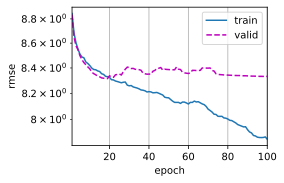

In [ ]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 5, 0, 64  # 者对输入特征值做了标准化，使得特征值较小，同时输出值房价较大，所以nn的权重都较大，所以学习率要相应较大才能加快收敛速度。
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr,
                          weight_decay, batch_size)
print(f'{k}-折验证: 平均训练log rmse: {float(train_l):f}, '
      f'平均验证log rmse: {float(valid_l):f}')

## 提交Kaggle预测

选择一个最合适的超参数组合

In [ ]:
def train_and_pred(train_features, test_features, train_labels, test_data,
                   num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None,
                        num_epochs, lr, weight_decay, batch_size)  # 只要训练集的loss，不计算验证集的loss
    d2l.plot(np.arange(1, num_epochs + 1), [train_ls], xlabel='epoch',
             ylabel='log rmse', xlim=[1, num_epochs], yscale='log')
    print(f'训练log rmse：{float(train_ls[-1]):f}')
    # 将网络应用于测试集。
    preds = net(test_features).detach().numpy()  # 剥离计算图再转换为numpy数组，避免计算图中存在梯度
    # 将其重新格式化以导出到Kaggle
    test_data['SalePrice'] = pd.Series(preds.reshape(1, -1)[0]) # 构建pandas序列
    submission = pd.concat([test_data['Id'], test_data['SalePrice']], axis=1) # 列方向拼接
    submission.to_csv('submission.csv', index=False) # 不包含索引列（0， 1， 2）

训练log rmse：7.962638


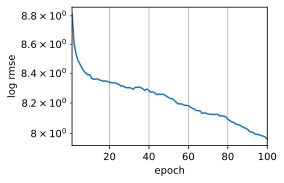

In [26]:
train_and_pred(train_features, test_features, train_labels, test_data,
               num_epochs, lr, weight_decay, batch_size)